# TP-15 : Projet final - Analyse visuelle 
# Contexte

Ce projet final integre toutes les competences de visualisation acquises. Vous devez realiser une
analyse visuelle complete sur un sujet de votre choix et la presenter de maniere professionnelle.

# Enonce
Partie A : Choix du sujet et des donnees

# education: analyse des incidents et les effets sur l'education

1 - frequence des incidents par region
2- evolution dans le temps
3 ZONES a risque eleve
4 pression sur les ecols
5 descolarisation potentiel
6 REcommendation(construction d'ecol temporaire, education d'urgence,)

In [ ]:
import  seaborn as sns
import plotly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl


### importation du dataframe

In [3]:
df= pd.read_excel("pdi-gcorr-burkinafaso-may2025.xlsx")

#### operation exploratoire

In [6]:
# Afficher les 5 premières lignes
print("\n les 5 premieres lignes: ")
print(df.head())

# Vérifier les types de données et les valeurs manquantes
print("\n information sur le dataset :")
print(df.info())

# Statistiques descriptives pour voir l'ampleur des incidents
print("\n les statistiques descriptives : ")
print(df.describe())
df.shape


 les 5 premieres lignes: 
    Date Choc  Choc Year  Choc Month  Choc Day Incident #  \
0  2025-04-25       2025           4        25    I-59750   
1  2025-04-30       2025           4        30    I-57106   
2  2025-04-12       2025           4        12    I-35880   
3  2025-04-14       2025           4        14    I-22639   
4  2025-04-03       2025           4         3    I-22626   

             Alerte ID Localisation du premier déplacement  \
0  667_250425_KOSNOU_1       Boucle du Mouhoun_Kossi_Nouna   
1    666_250430_GOUDIA                    Est_Gourma_Diabo   
2    665_250412_YATTAN                Nord_Yatenga_Tangaye   
3    664_250414_KOSSÔN        Boucle du Mouhoun_Kossi_Sônô   
4  663_250403_YATOUA-1             Nord_Yatenga_Ouahigouya   

                   Zone d’origine  \
0  Boucle du Mouhoun_Kossi_Barani   
1                Est_Gourma_Diabo   
2            Nord_Yatenga_Tangaye   
3    Boucle du Mouhoun_Kossi_Sônô   
4                Nord_Loroum_Bahn   

          

(154, 22)

# 2. Nettoyage (Data Cleaning)

In [14]:
# recherche des valeurs manquantes
print(df.isna)

print("\somme des valeurs manquantes: ")
print(df.isna().sum())

<bound method DataFrame.isna of       Date Choc  Choc Year  Choc Month  Choc Day Incident #  \
0    2025-04-25       2025           4        25    I-59750   
1    2025-04-30       2025           4        30    I-57106   
2    2025-04-12       2025           4        12    I-35880   
3    2025-04-14       2025           4        14    I-22639   
4    2025-04-03       2025           4         3    I-22626   
..          ...        ...         ...       ...        ...   
149  2024-05-26       2024           5        26       I-37   
150  2024-05-22       2024           5        22       I-35   
151  2024-05-20       2024           5        20       I-34   
152  2024-05-20       2024           5        20       I-33   
153  2024-05-24       2024           5        24       I-32   

                  Alerte ID Localisation du premier déplacement  \
0       667_250425_KOSNOU_1       Boucle du Mouhoun_Kossi_Nouna   
1         666_250430_GOUDIA                    Est_Gourma_Diabo   
2         

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\user\AppData\Local\Temp\ipykernel_62340\3114874532.py:4: SyntaxWarning: invalid escape sequence '\s'
  print("\somme des valeurs manquantes: ")


In [15]:
print(df.notna().sum())

Date Choc                              154
Choc Year                              154
Choc Month                             154
Choc Day                               154
Incident #                             154
Alerte ID                              154
Localisation du premier déplacement    154
Zone d’origine                         153
Besoins prioritaires                   154
Sévérité                               154
Type de choc                           154
Déplacement #                          154
Date d’arrivée                         154
Région d’accueil                       154
Commune d’accueil                      154
Villages d’accueil                     154
PDI Ménage                             154
PDI Personne                           154
Hommes                                 142
Femmes                                 141
Garçons                                127
Filles                                 121
dtype: int64


In [16]:
print(df.isna().sum())

Date Choc                               0
Choc Year                               0
Choc Month                              0
Choc Day                                0
Incident #                              0
Alerte ID                               0
Localisation du premier déplacement     0
Zone d’origine                          1
Besoins prioritaires                    0
Sévérité                                0
Type de choc                            0
Déplacement #                           0
Date d’arrivée                          0
Région d’accueil                        0
Commune d’accueil                       0
Villages d’accueil                      0
PDI Ménage                              0
PDI Personne                            0
Hommes                                 12
Femmes                                 13
Garçons                                27
Filles                                 33
dtype: int64


####  gestion des valeurs manquante

In [20]:
# Remplacer pour la colonne 'filles'
df['Filles'] = df['Filles'].fillna(df['Filles'].mean())

# Remplacer pour la colonne 'garçons'
df['Garçons'] = df['Garçons'].fillna(df['Garçons'].mean())

In [21]:
print(df.isna().sum())

Date Choc                               0
Choc Year                               0
Choc Month                              0
Choc Day                                0
Incident #                              0
Alerte ID                               0
Localisation du premier déplacement     0
Zone d’origine                          1
Besoins prioritaires                    0
Sévérité                                0
Type de choc                            0
Déplacement #                           0
Date d’arrivée                          0
Région d’accueil                        0
Commune d’accueil                       0
Villages d’accueil                      0
PDI Ménage                              0
PDI Personne                            0
Hommes                                 12
Femmes                                 13
Garçons                                 0
Filles                                  0
dtype: int64


In [24]:
# creer une collone enfant pour metre les somme de filles et de garçon
# Création de la colonne 'enfant'
df['Enfant'] = df['Filles'] + df['Garçons']


In [30]:
pd.set_option('display.width', 1000)
print(df.head())


    Date Choc  Choc Year  Choc Month  Choc Day Incident #            Alerte ID Localisation du premier déplacement                  Zone d’origine                               Besoins prioritaires Sévérité       Type de choc Déplacement # Date d’arrivée   Région d’accueil Commune d’accueil                 Villages d’accueil  PDI Ménage  PDI Personne  Hommes  Femmes  Garçons  Filles  Enfant
0  2025-04-25       2025           4        25    I-59750  667_250425_KOSNOU_1       Boucle du Mouhoun_Kossi_Nouna  Boucle du Mouhoun_Kossi_Barani                                 Vivres, Abris, NFI   Medium  Security Incident        D-2827     2025-05-04  Boucle du Mouhoun             Nouna                              Nouna         100          1700   299.0   406.0    398.0   597.0   995.0
1  2025-04-30       2025           4        30    I-57106    666_250430_GOUDIA                    Est_Gourma_Diabo                Est_Gourma_Diabo  Selon les informations émanant de l'action soc...   Medium  Secu

In [29]:
print(df.columns)

Index(['Date Choc', 'Choc Year', 'Choc Month', 'Choc Day', 'Incident #', 'Alerte ID', 'Localisation du premier déplacement', 'Zone d’origine', 'Besoins prioritaires', 'Sévérité', 'Type de choc', 'Déplacement #', 'Date d’arrivée', 'Région d’accueil', 'Commune d’accueil', 'Villages d’accueil', 'PDI Ménage', 'PDI Personne', 'Hommes', 'Femmes', 'Garçons', 'Filles', 'Enfant'], dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_62340\955017595.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_zones.values, y=top_zones.index, palette = colors)


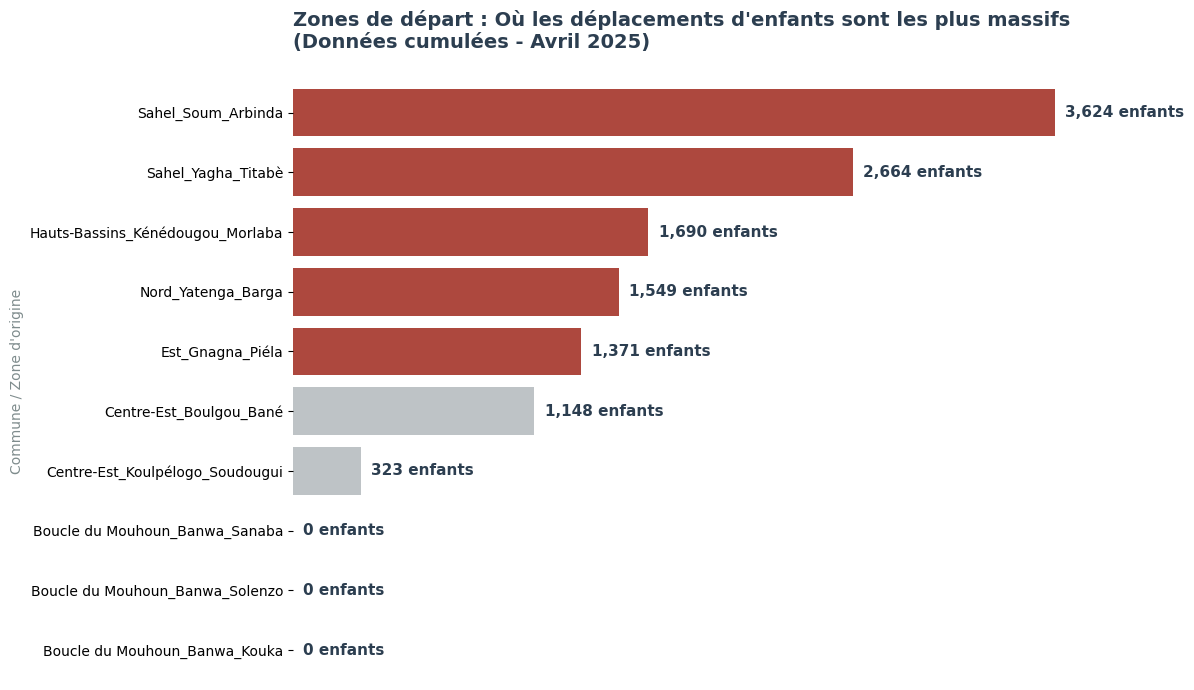

In [34]:




# Étape 1 : Calculer l'évolution par mois pour chaque zone d'origine
# On crée un tableau croisé pour voir la somme des enfants par zone et par mois
pivot_enfant = df.pivot_table(index='Zone d’origine', 
                             columns='Choc Month', 
                             values='Enfant', 
                             aggfunc='sum').fillna(0)

# Étape 2 : Calculer la variation (exemple : Avril vs Mars ou simplement le total d'Avril)
# Si tu as plusieurs mois, on calcule la différence. Ici, on prend le mois le plus récent (4)
derniere_col = pivot_enfant.columns[-1]
# On trie pour avoir les 10 zones les plus touchées
top_zones = pivot_enfant[derniere_col].sort_values(ascending=False).head(10)

# Étape 3 : Visualisation (Principes de Storytelling with Data)
plt.figure(figsize=(12, 7))

# Palettes sequentielles (donnees continues)
sns.color_palette("Blues", 6)
sns.color_palette("YlOrRd", 6)

ax = sns.barplot(x=top_zones.values, y=top_zones.index, palette = colors)

# --- APPLICATION DU DECLUTTERING (COURS DATA VIZ) ---

# 1. Supprimer le cadre (Border)
for spine in ax.spines.values():
    spine.set_visible(False)

# 2. Supprimer les lignes de la grille et l'axe X
ax.get_xaxis().set_visible(False)

# 3. Étiquetage direct des données (pour éviter de chercher sur l'axe)
for i, v in enumerate(top_zones.values):
    ax.text(v + 50, i, f"{int(v):,} enfants", va='center', fontsize=11, fontweight='bold', color='#2C3E50')

# 4. Titre informatif (Storytelling)
plt.title("Zones de départ : Où les déplacements d'enfants sont les plus massifs\n(Données cumulées - Avril 2025)", 
          loc='left', fontsize=14, fontweight='bold', pad=25, color='#2C3E50')

plt.ylabel("Commune / Zone d'origine", fontsize=10, color='#7F8C8D')
plt.xlabel("") # Suppression car étiquetage direct

plt.tight_layout()
plt.show()